<a href="https://colab.research.google.com/github/boruizhang/representations/blob/main/04_bert_self_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# pip install -U transformers torch matplotlib

import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel

def plot_attention_heatmap(
    text: str,
    model_name: str = "bert-base-uncased",
    layer: int = -1,
    head: int = 0,
    max_length: int = 64,
):
    """
    Visualize Transformer self-attention for a single sentence as a heatmap.

    - layer: which layer's attention to visualize (e.g., -1 = last layer)
    - head: which attention head to visualize
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModel.from_pretrained(model_name, output_attentions=True).to(device)
    model.eval()

    # Tokenize
    enc = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
        add_special_tokens=True,
    ).to(device)

    # Forward pass (no gradients needed)
    with torch.no_grad():
        out = model(**enc)

    # out.attentions: tuple of length num_layers
    # each item shape: (batch, num_heads, seq_len, seq_len)
    attentions = out.attentions
    att = attentions[layer][0, head].detach().cpu()  # (seq_len, seq_len)

    # Convert token ids -> readable token strings
    token_ids = enc["input_ids"][0].detach().cpu().tolist()
    tokens = tokenizer.convert_ids_to_tokens(token_ids)

    # Plot heatmap
    fig, ax = plt.subplots(figsize=(max(8, len(tokens) * 0.45), max(6, len(tokens) * 0.45)))
    im = ax.imshow(att, interpolation="nearest")  # no explicit colors requested

    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90)
    ax.set_yticklabels(tokens)

    ax.set_title(f"Self-attention heatmap | model={model_name} | layer={layer} | head={head}")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()



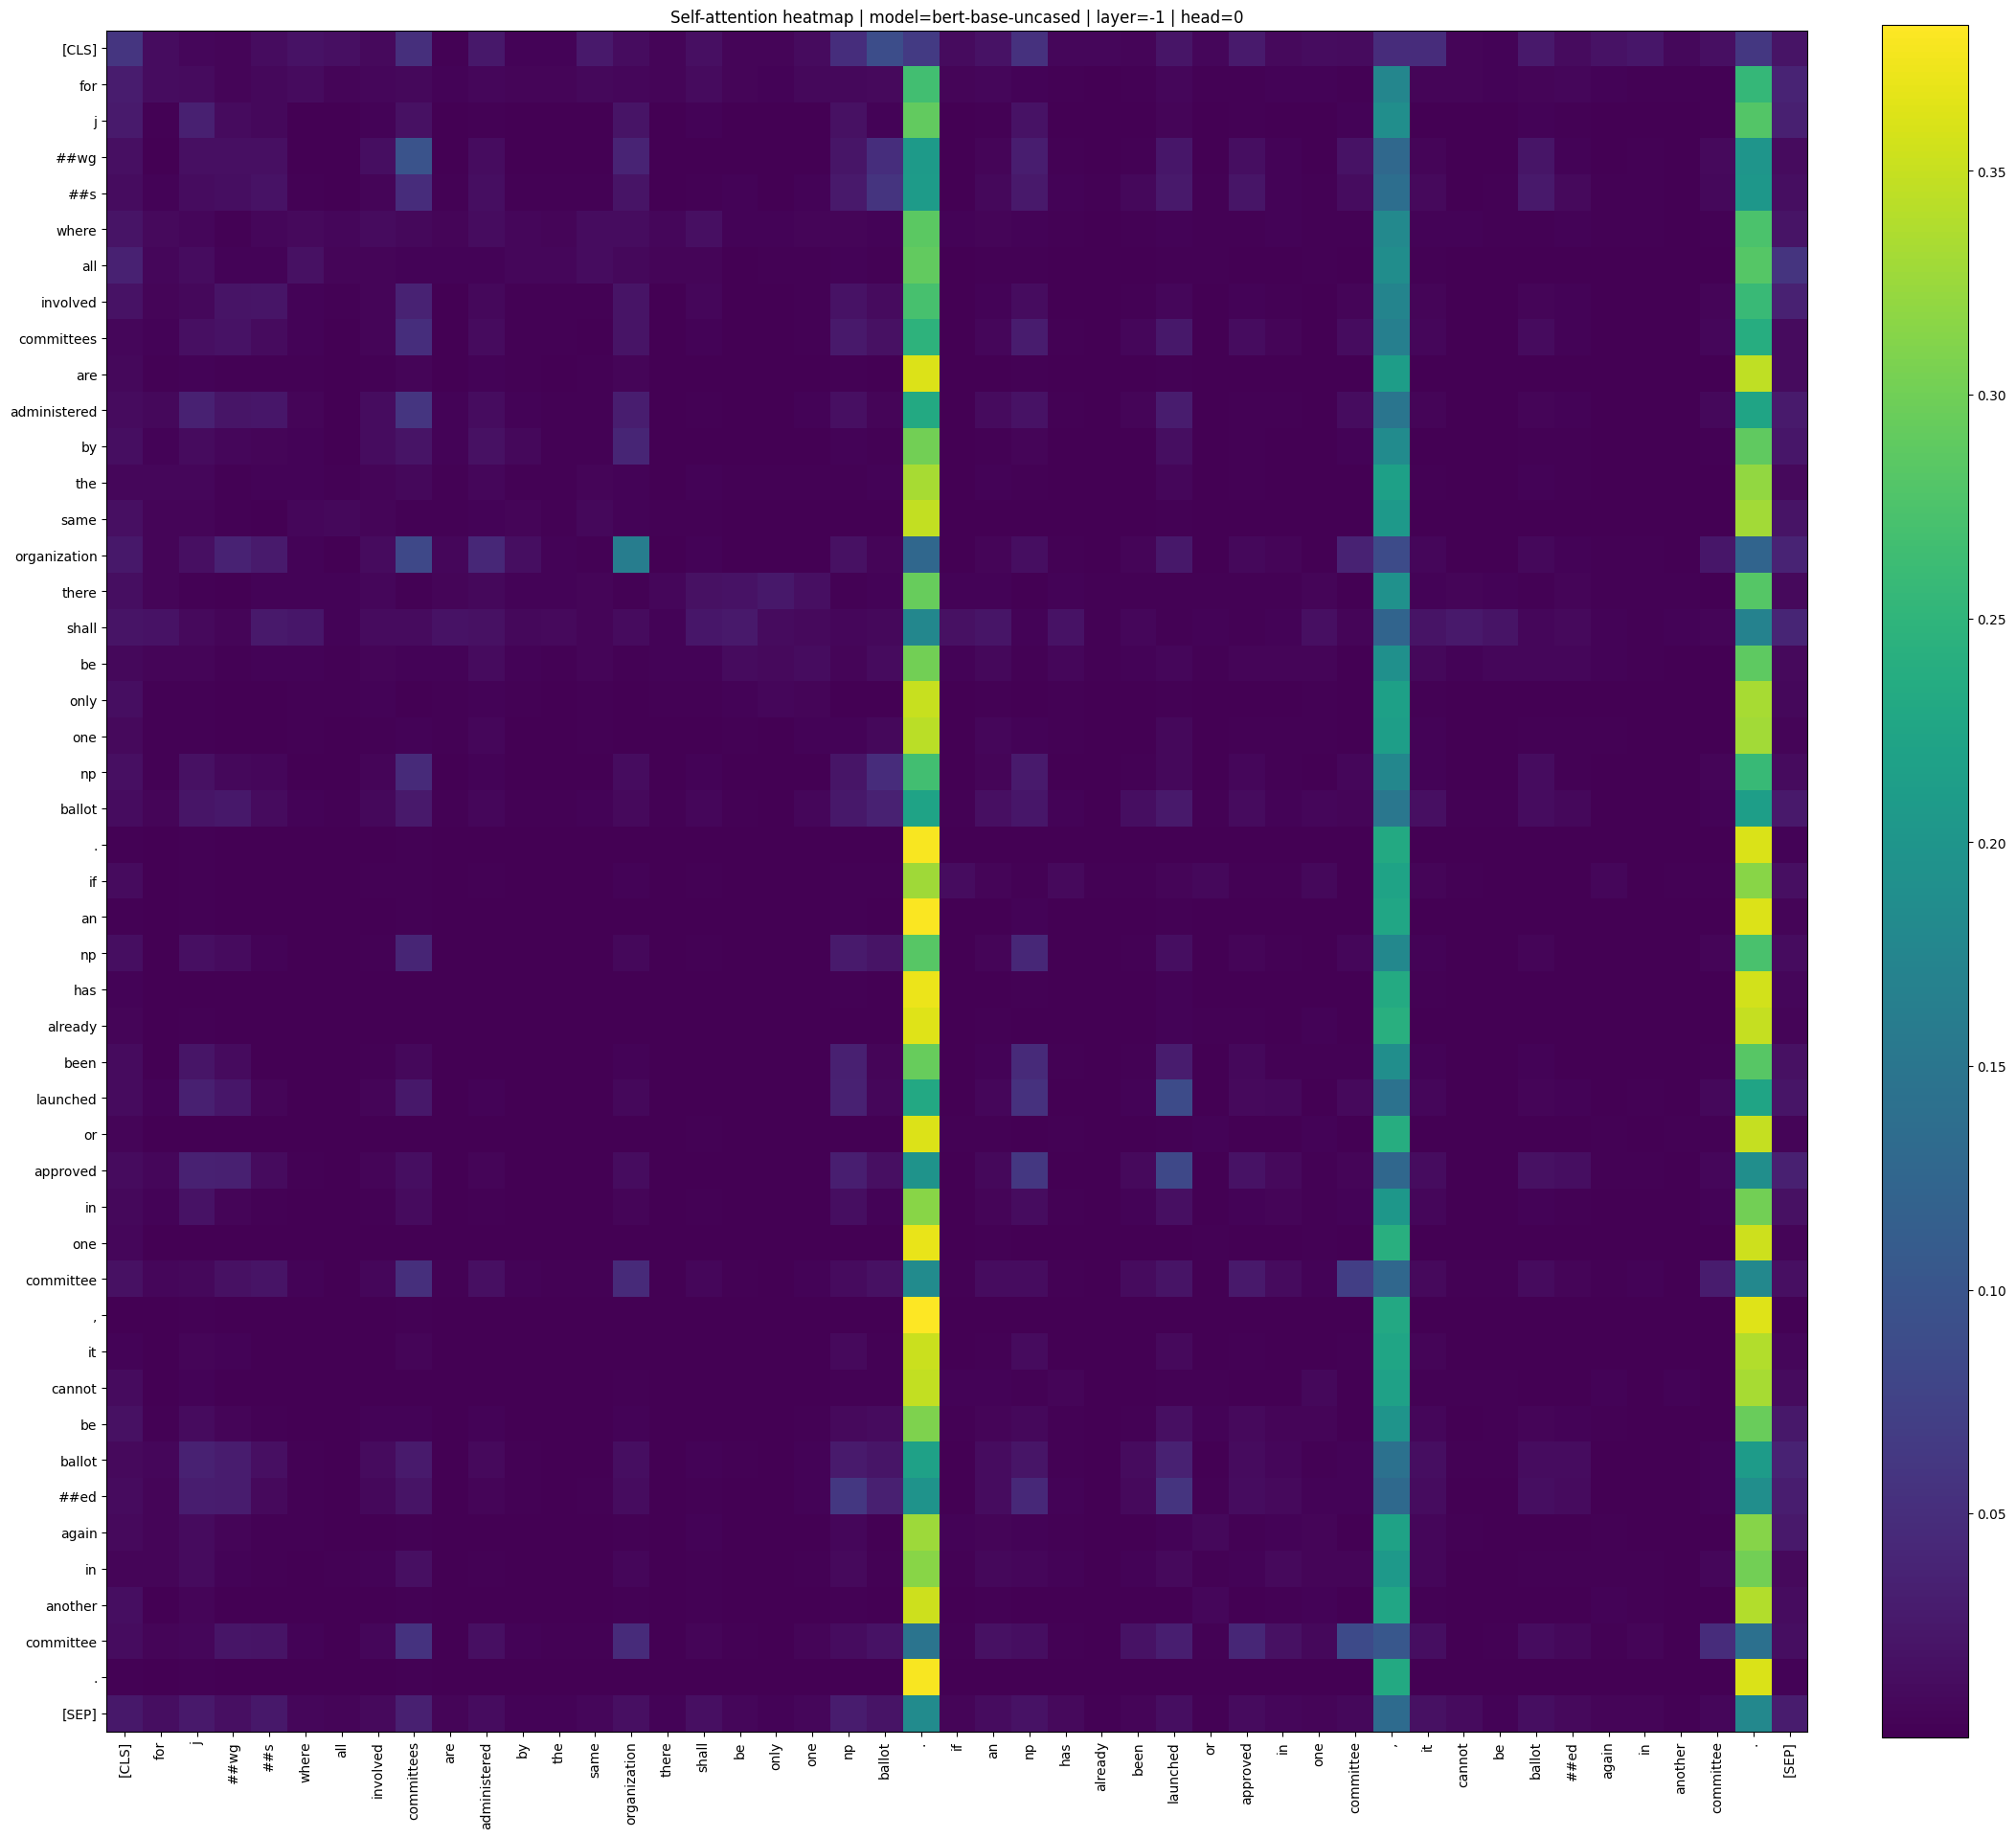

In [ ]:

if __name__ == "__main__":
    plot_attention_heatmap(
       # "The quick brown fox jumps over the lazy dog.", # 1885 Boston Journal
        "For JWGs where all involved committees are administered by the same organization there shall be only one NP ballot. If an NP has already been launched or approved in one committee, it cannot be balloted again in another committee.",
        model_name="bert-base-uncased",
        layer=-1,
        head=0,
    )